# Rae2822 2D Wing Slice Model

### Import Library

In [ ]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

### Loading Data

In [71]:
folder_path = Path("./data/rae2822/angvar_sa")
case_dirs = sorted(
    [path for path in folder_path.iterdir() if path.is_dir()],
    key=lambda path: float(path.name),
) if folder_path.exists() else []

if not case_dirs:
    raise FileNotFoundError(
        f"No AoA case folders found in {folder_path.resolve()}. "
        "Download the Kaggle dataset and place rae2822/angvar_sa under data/."
    )

master_df = []

for case_dir in case_dirs:
    surface_csv = case_dir / "surface_flow.csv"
    if not surface_csv.exists():
        raise FileNotFoundError(f"Missing surface_flow.csv in {case_dir}")

    df = pd.read_csv(surface_csv)
    df['AoA'] = float(case_dir.name)
    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)
full_data = full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']]
# full_data = full_data.dropna()
print(full_data[full_data.isna().any(axis=1)])


Empty DataFrame
Columns: [Pressure_Coefficient, AoA, x, y]
Index: []


In [72]:
print(f"Total rows: {len(full_data)}")
full_data[['Pressure_Coefficient', 'AoA', 'x', 'y']].head()

Total rows: 8640


,Pressure_Coefficient,AoA,x,y
0,0.264443,-1.0,0.985397,0.000943
1,0.277211,-1.0,0.969573,0.001489
2,0.287710,-1.0,0.952680,0.001679
3,0.288603,-1.0,0.934996,0.001511
4,0.284074,-1.0,0.916822,0.000923


Text(0.5, 1.0, 'Sample Case: AoA = 0.0°')

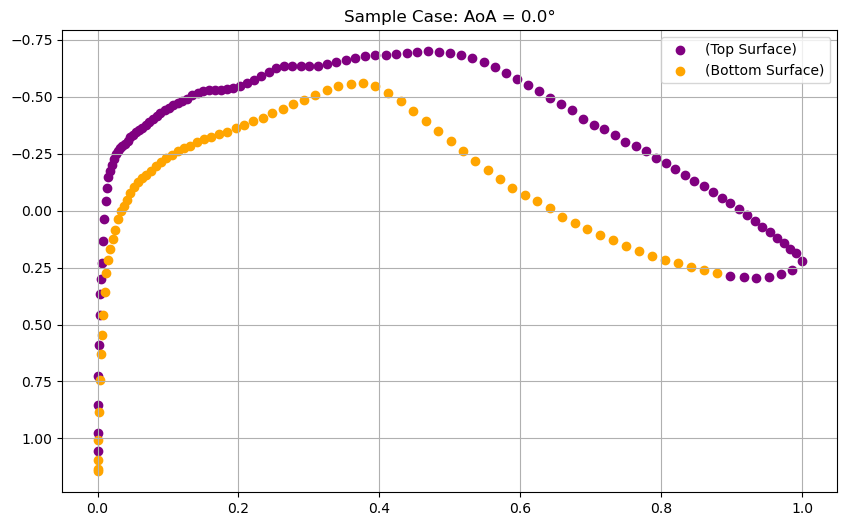

In [73]:
sample_case = full_data[full_data['AoA'] == 0.0]

plt.figure(figsize=(10, 6))
top_surface = sample_case[sample_case['y'] > 0].sort_values(by='x')
bottom_surface = sample_case[sample_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Pressure_Coefficient'], color='purple', label='(Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Pressure_Coefficient'],color='orange', label='(Bottom Surface)')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.title("Sample Case: AoA = 0.0°")

### Model Random Forest Regression

In [74]:
aoa_values = full_data['AoA'].unique()
features = ['x', 'y', 'AoA']
target = 'Pressure_Coefficient'
len(aoa_values)
aoa_values


array([-1.  , -0.5 ,  0.  ,  0.5 ,  1.  ,  1.5 ,  2.  ,  2.5 ,  3.  ,
        3.5 ,  4.  ,  4.5 ,  5.  ,  5.5 ,  6.  ,  6.5 ,  7.  ,  7.5 ,
        8.  ,  8.5 ,  9.  ,  9.5 , 10.  , 10.25, 10.5 , 10.75, 11.  ,
       11.25, 11.5 , 11.75, 12.  , 12.25, 12.5 , 12.75, 13.  , 13.25,
       13.5 , 13.75, 14.  , 15.  , 16.  , 17.  , 18.  , 19.  , 20.  ])

In [75]:
# Train test split Leave-one-out
# We only have 4000 row of data
# to prevent model cheating (Data Leakage) 
# we use leave-one-group-out cross validation
rdfr_model = RandomForestRegressor(n_estimators=300, random_state=42, oob_score=True)
scores = []
r2Scores = []

for aoa in aoa_values:
    train = full_data[full_data['AoA'] != aoa]
    test  = full_data[full_data['AoA'] == aoa]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    rdfr_model.fit(X_train, y_train)
    prediction = rdfr_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)
    scores.append(rmse)
    r2Scores.append(r2)

print("RMSE score: ", sum(scores)/len(scores))
print("R2 score: ", sum(r2Scores)/len(r2Scores))


RMSE score:  0.06158638259342079
R2 score:  0.98748508192024


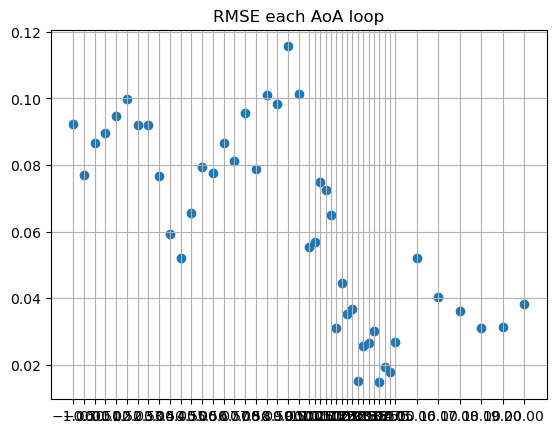

In [77]:

plt.scatter(aoa_values, scores)
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(aoa_values)
plt.grid(True)
plt.title("RMSE each AoA loop")
plt.show()

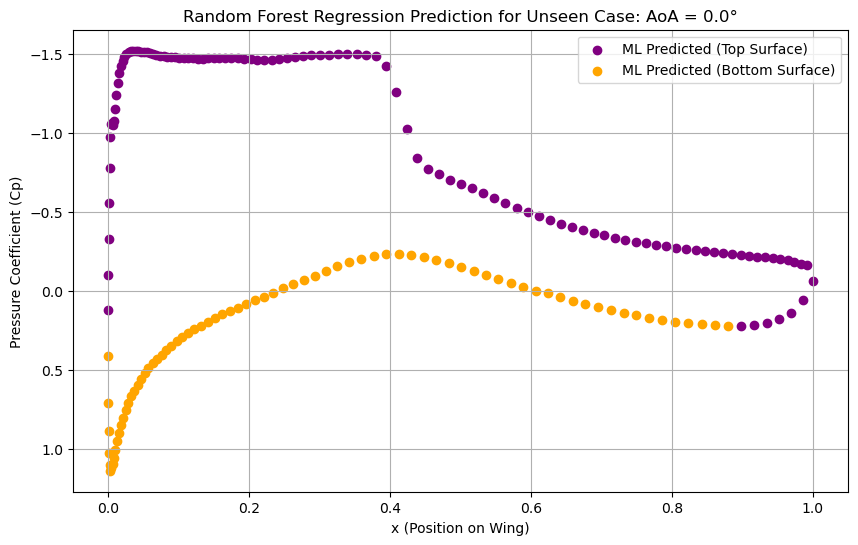

In [80]:
rdfr_model.fit(full_data[features], full_data[target])
new_case = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy()

new_case['AoA'] = 5.5

predicted_cp = rdfr_model.predict(new_case[['x', 'y', 'AoA']])

new_case['Predicted_Cp'] = predicted_cp

plt.figure(figsize=(10, 6))
top_surface = new_case[new_case['y'] > 0].sort_values(by='x')
bottom_surface = new_case[new_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Predicted_Cp'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Predicted_Cp'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Random Forest Regression Prediction for Unseen Case: AoA = 0.0°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()

### Model Polynomial Regression

In [99]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("lin", LinearRegression())
])

scores = []
r2Scores = []

for aoa in aoa_values:
    train = full_data[full_data['AoA'] != aoa]
    test  = full_data[full_data['AoA'] == aoa]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    poly_model.fit(X_train, y_train)

    prediction = poly_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)
    scores.append(rmse)
    r2Scores.append(r2)

print("RMSE score: ", sum(scores)/len(scores))
print("R2 score: ", sum(r2Scores)/len(r2Scores))

RMSE score:  0.4510490763839333
R2 score:  0.4911929509831183


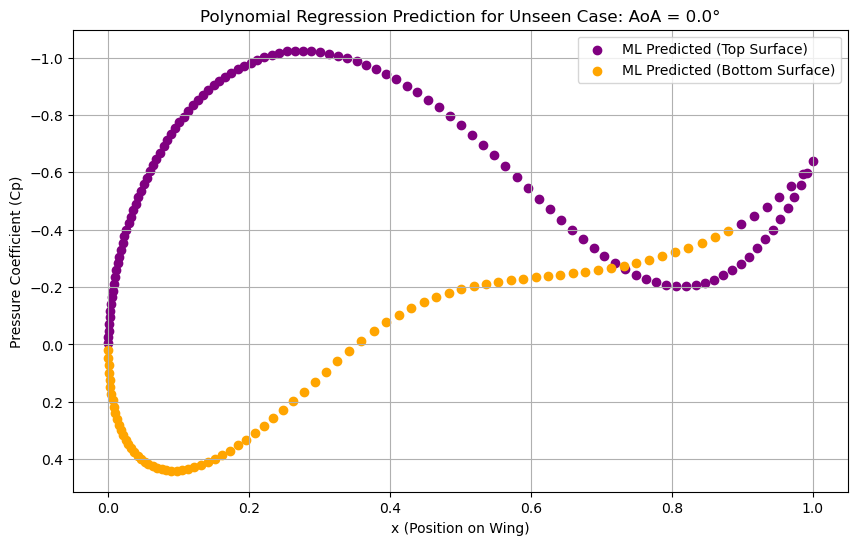

In [111]:
poly_model.fit(full_data[features], full_data[target])
new_case = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy()

new_case['AoA'] = 0.0

predicted_cp = poly_model.predict(new_case[['x', 'y', 'AoA']])

new_case['Predicted_Cp'] = predicted_cp

plt.figure(figsize=(10, 6))
top_surface = new_case[new_case['y'] > 0].sort_values(by='x')
bottom_surface = new_case[new_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Predicted_Cp'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Predicted_Cp'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Polynomial Regression Prediction for Unseen Case: AoA = 0.0°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()

### Model Gradient Boosting

In [101]:
gbc = GradientBoostingRegressor(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=3 )

scores = []
r2Scores = []

for aoa in aoa_values:
    train = full_data[full_data['AoA'] != aoa]
    test  = full_data[full_data['AoA'] == aoa]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    gbc.fit(X_train, y_train)
    prediction = gbc.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)
    scores.append(rmse)
    r2Scores.append(r2)

print("RMSE score: ", sum(scores)/len(scores))
print("R2 score: ", sum(r2Scores)/len(r2Scores))
    

RMSE score:  0.22936433121972583
R2 score:  0.7028790935721196


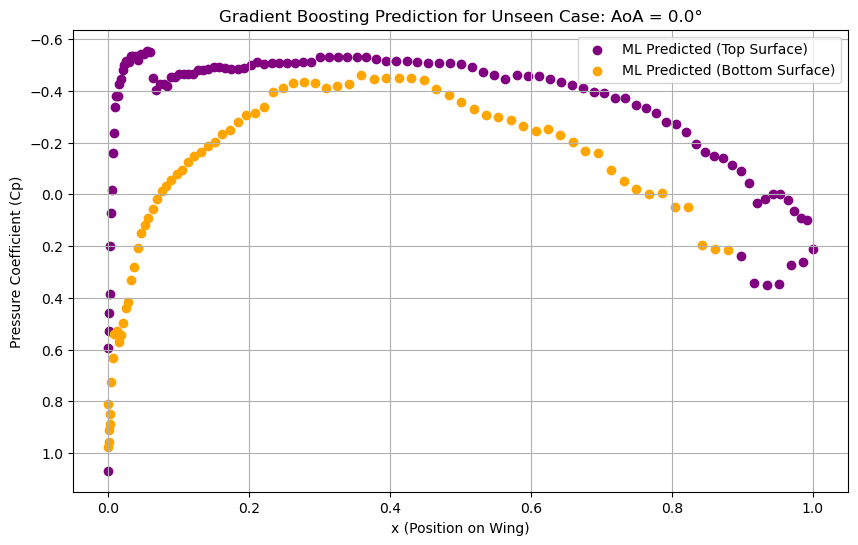

In [110]:
gbc.fit(full_data[features], full_data[target])
new_case = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy()

new_case['AoA'] = 0.0

predicted_cp = gbc.predict(new_case[['x', 'y', 'AoA']])

new_case['Predicted_Cp'] = predicted_cp

plt.figure(figsize=(10, 6))
top_surface = new_case[new_case['y'] > 0].sort_values(by='x')
bottom_surface = new_case[new_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Predicted_Cp'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Predicted_Cp'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Gradient Boosting Prediction for Unseen Case: AoA = 0.0°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()